In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm


In [2]:
def f_base(x):
    ans = 100*(x[1] - x[0]**3)**2 + x[1]**2 + x[0]**2
    return ans

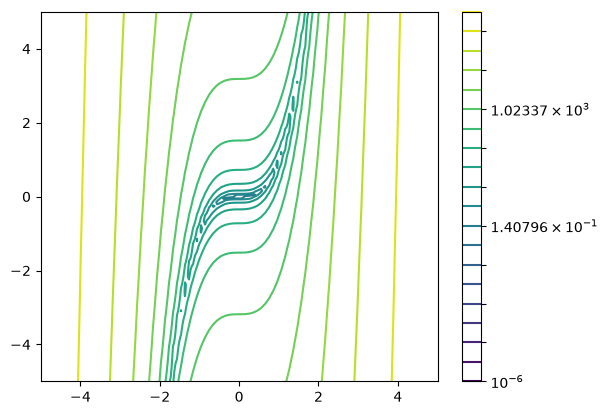

In [3]:

x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
Z = f_base((X, Y))

Z_log = Z - Z.min() + 1e-6

levels = np.logspace(np.log10(Z_log.min()), np.log10(Z_log.max()), 20)

plt.contour(X, Y, Z_log, levels=levels, norm=LogNorm())
plt.colorbar()
plt.show()

In [47]:
def method_1(eps, start, alpha=1.0, h=1e-10):
    iter_c = 0
    f_call_c = 0

    def f(x):
        nonlocal f_call_c
        f_call_c += 1
        return f_base(x)

    def g(x):
        dx1 = (
            f((x[0] + h, x[1])) -
            f((x[0] - h, x[1]))
        ) / (2 * h)

        dx2 = (
            f((x[0], x[1] + h)) -
            f((x[0], x[1] - h))
        ) / (2 * h)

        return np.array([dx1, dx2], dtype=float)

    x = np.array(start, dtype=float)
    dx = g(x)

    run = [x.copy()]

    while np.linalg.norm(dx) > eps:
        # Начинаем поиск шага
        current_f = f(x)
        current_alpha = alpha

        while current_alpha > 1e-15:
            new_x = x - current_alpha * dx

            if f(new_x) < current_f:
                break

            current_alpha *= 0.5

        # Подходящий шаг не найден
        if current_alpha <= 1e-15:
            break

        # Делаем шаг
        x = new_x
        alpha = current_alpha

        # Считаем новый градиент
        dx = g(x)

        iter_c += 1
        run.append(x.copy())
        if (iter_c % 100000 in [1, 2, 3]): 
            print(x) 
            print(dx)

    return x, f(x), iter_c, f_call_c, run

In [16]:
# Метод минимизации по правильному симплексу
def method_2(eps, start, alpha=1e-3):
    iter_c = 0
    f_call_c = 0

    def f(x):
        nonlocal f_call_c
        f_call_c += 1
        return f_base(x)

    a = np.array(start, dtype=float)
    b = a + np.array((alpha, 0), dtype=float)
    c = a + np.array((alpha/2, math.sqrt(3)/2 * alpha), dtype=float)
    run = [a.copy()]

    s = [(i, f(i)) for i in [a, b, c]]
    s.sort(key=lambda x: x[1], reverse=True)

    while sum([abs(f - s[0][1]) for _, f in s]) > eps:
        iter_c += 1
        x = s[1][0] + s[2][0] - s[0][0]
        fx = f(x)

        if fx < s[0][1]:
            s[0] = (x, fx)
            run.append(x.copy())
           
        else:
            s[1] = ((s[0][0]+s[1][0])/2, f(s[0][0]+s[1][0]))
            s[2] = ((s[0][0]+s[1][0])/2, f(s[0][0]+s[1][0]))

        s.sort(key=lambda x: x[1], reverse=True)
            
    return (s[0][0], s[0][1], iter_c, f_call_c, run)

In [48]:
eps = 1e-6
runs = []
mt_runs = []
for (x, y) in ((1, 1), (10, 0), (-5, -3)):
    (xm, f, iter_c, f_call_c, run) = method_1(eps, (x, y))
    print(eps, iter_c, f_call_c, (xm[0], xm[1]), f)
    mt_runs.append(run)
    
runs.append(mt_runs)
print()
mt_runs = []
for (x, y) in ((1, 1), (10, 0), (-5, -3)):
    (xm, f, iter_c, f_call_c, run) = method_2(eps, (x, y))
    print(eps, iter_c, f_call_c, (xm[0], xm[1]), f)
    mt_runs.append(run)

[-8.2740371e-08 -8.2740371e-08]
[-1.65480742e-07 -1.67135549e-05]
[-8.14475527e-08  4.78342770e-08]
[-1.62895105e-07  9.66252395e-06]
[-8.01749347e-08 -2.76541914e-08]
[-1.60349869e-07 -5.58614666e-06]
1e-06 7 54 (np.float64(-7.52802264314235e-08), np.float64(-3.0892137869207764e-09)) 6.6309799155175704e-15
[-4.30510821  0.04771294]
[-887842.03398973   15968.10761839]
[-4.09343017  0.04390585]
[-690035.8130224    13726.82163492]
[-3.92891281  0.04063312]
[-562095.3743346    12138.04353029]
[-0.68440541 -0.32273229]
[-0.76472384 -1.0753487 ]
[-0.68440523 -0.32273203]
[-0.76472384 -1.0753487 ]
[-0.68440505 -0.32273177]
[-0.76472384 -1.07534759]
[-0.66615829 -0.29774587]
[-0.76601059 -1.0208695 ]
[-0.66615811 -0.29774563]
[-0.76601114 -1.0208695 ]
[-0.66615793 -0.29774538]
[-0.76601114 -1.02086839]
[-0.64787871 -0.27404299]
[-0.76738976 -0.96767844]
[-0.64787852 -0.27404276]
[-0.76739004 -0.96767788]
[-0.64787834 -0.27404253]
[-0.76738976 -0.9676776 ]
[-0.62956696 -0.25159407]
[-0.7686845

KeyboardInterrupt: 

IndexError: list index out of range

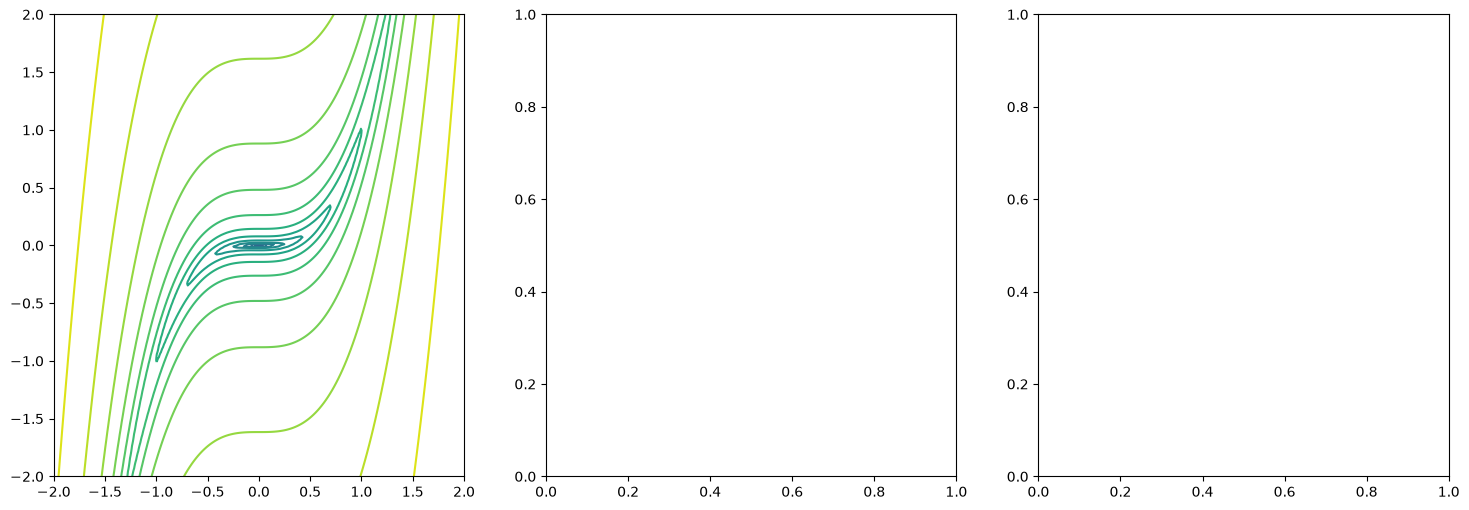

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

ranges = [
    (-2, 2, -2, 2),
    (-1, 11, -1, 11),
    (-6, 2, -6, 2)
]

for i, (ax, run, (x_min, x_max, y_min, y_max)) in enumerate(
    zip(axes, runs, ranges)
):
    # Grid for this subplot
    x = np.linspace(x_min, x_max, 200)
    y = np.linspace(y_min, y_max, 200)
    X, Y = np.meshgrid(x, y)

    Z = f_base((X, Y))

    # Shift because log scale requires positive values
    Z_log = Z - Z.min() + 1e-6

    levels = np.logspace(
        np.log10(Z_log.min()),
        np.log10(Z_log.max()),
        20
    )

    # Contour plot
    ax.contour(
        X, Y, Z_log,
        levels=levels,
        norm=LogNorm()
    )

    # Trajectory
    x_path = [point[0] for point in run]
    y_path = [point[1] for point in run]

    ax.plot(
        x_path,
        y_path,
        marker='o',
        color='red'
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    ax.set_xlabel("x₁")
    ax.set_ylabel("x₂")
    ax.set_title(f"Run {i + 1}")
    ax.grid(True)

plt.tight_layout()
plt.show()